In [ ]:
%load_ext autoreload
%autoreload 2

import sklearn
import scipy 
import numpy as np
import pandas as pd
import os
import sys

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "0"
sys.path.append(os.path.abspath("src"))
import jdcoot
import math
from scipy.io import loadmat

from jdcoot.models.discrete_unsupervised_jdcoot import discrete_unsupervised_jdcoot
from jdcoot.models.discrete_semisupervised_jdcoot import discrete_semisupervised_jdcoot
from jdcoot.models.discrete_partial_jdcoot import discrete_partial_jdcoot
from jdcoot.models.discrete_unsupervised_coot import discrete_unsupervised_coot
from jdcoot.models.discrete_semisupervised_coot import discrete_semisupervised_coot
from jdcoot.models.discrete_partial_coot import discrete_partial_coot
from jdcoot.models.discrete_semisupervised_reference import discrete_semisupervised_reference
from jdcoot.models.discrete_partial_reference import discrete_partial_reference

S_data = pd.read_csv("data.exp.csv")
T_data = pd.read_csv("data.met.csv")
#S_data = pd.read_csv("data_omique_S.csv")
#T_data = pd.read_csv("data_omique_T.csv")



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
S_data = S_data.iloc[:, 2:]
T_data = T_data.iloc[:, 2:]

# renommer les colonnes
X_colsS = ['X'+str(i) for i in range(S_data.shape[1]-1)]
X_colsT = ['X'+str(i) for i in range(T_data.shape[1]-1)]

S_data.columns = X_colsS + ['Z']
T_data.columns = X_colsT + ['Z']

# convertir Z comme dans R
mapping = {
    "CIMP-low": 0,
    "CIMP-intermediate": 1,
    "CIMP-high": 2
}

S_data["Z"] = S_data["Z"].map(mapping)
T_data["Z"] = T_data["Z"].map(mapping)

S_data = S_data.dropna(subset=['Z'])
T_data = T_data.dropna(subset=['Z'])

In [ ]:
# identifiants des deux datasets
source_ids = S_data["X1"]
target_ids = T_data["X1"]

# trouver les individus dans target mais pas dans source
missing_in_source = target_ids[~target_ids.isin(source_ids)]

print("Individus dans target mais pas dans source :")
print(missing_in_source)
T_data = T_data[~T_data["X1"].isin(missing_in_source)]

# vérifier
print(T_data.shape)


Individus dans target mais pas dans source :
Series([], Name: X1, dtype: float64)
(0, 370366)


In [46]:
source.shape

(78, 35219)

In [47]:
target.shape

(79, 370368)

In [48]:
from jdcoot.utils import xcolumns
from sklearn.feature_selection import VarianceThreshold
source = S_data
target = T_data
x_source = source.loc[:, xcolumns(source)].values
x_target = target.loc[:, xcolumns(target)].values
#selector = VarianceThreshold(threshold=0.4)
selector = VarianceThreshold(threshold=0.1)
#x_source_reduced = selector.fit_transform(x_source)
x_source_reduced = selector.fit_transform(x_source)
selector = VarianceThreshold(threshold=0.1)
#selector = VarianceThreshold(threshold=0.1)
x_target_reduced = selector.fit_transform(x_target)
#x_target_reduced = selector.fit_transform(x_source)
x_target_reduced.shape
X_df = pd.DataFrame(x_source_reduced, columns=['X'+str(i) for i in range(x_source_reduced.shape[1])])
X_df['Z'] = source['Z'].values
source = X_df
X_df = pd.DataFrame(x_target_reduced, columns=['X'+str(i) for i in range(x_target_reduced.shape[1])])
X_df['Z'] = target['Z'].values
target = X_df
source.shape, target.shape

ValueError: could not convert string to float: 'TCGA-OR-A5J1'

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
x_source_reduced2=x_source_reduced
corr_matrix = np.corrcoef(x_source_reduced.T, x_target_reduced.T)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation between source and target features")
plt.show()

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 78 and the array at index 1 has size 79

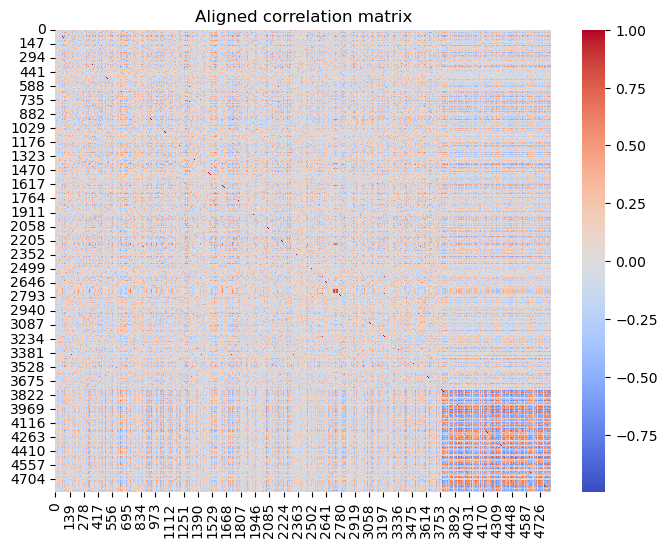

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

scaler_s = StandardScaler()
scaler_t = StandardScaler()

x_source_scaled = scaler_s.fit_transform(x_source_reduced)
x_target_scaled = scaler_t.fit_transform(x_target_reduced)


corr_matrix = np.corrcoef(
    x_source_scaled.T,
    x_target_scaled.T
)

p = x_source_scaled.shape[1]

corr_source_target = corr_matrix[:p, p:]

from scipy.optimize import linear_sum_assignment
row_ind, col_ind = linear_sum_assignment(-np.abs(corr_source_target))
x_target_scaled_aligned = x_target_scaled[:, col_ind]

signs = np.sign(corr_source_target[row_ind, col_ind])
x_target_scaled_aligned *= signs
#threshold = 0.6

#selected_cols = np.where(np.abs(corr_source_target)) > threshold)[0]
#selected_cols 
#x_source_selected = x_source_reduced[:, selected_cols]

corr_final = np.corrcoef(x_source_scaled.T, x_target_scaled_aligned.T)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_final, cmap="coolwarm", center=0)
plt.title("Aligned correlation matrix")
plt.show()

X_df = pd.DataFrame(x_source_scaled, columns=['X'+str(i) for i in range(x_source_scaled.shape[1])])
X_df['Z'] = source['Z'].values
source = X_df
X_df = pd.DataFrame(x_target_scaled_aligned, columns=['X'+str(i) for i in range(x_target_scaled_aligned.shape[1])])
X_df['Z'] = target['Z'].values
target = X_df

In [ ]:
target.shape

(78, 1078)

In [47]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(source))

# split stratifié sur Z
idx_source, idx_target = train_test_split(
    indices,
    test_size=0.5,
    stratify=source['Z'],
    random_state=42
)

# séparation
source_split = source.iloc[idx_source].reset_index(drop=True)
target_split = target.iloc[idx_target].reset_index(drop=True)

In [48]:
source = source_split
target = target_split

source.shape, target.shape

((39, 3757), (39, 1078))

In [25]:
print("Source:")
print(source_split["Z"].value_counts().sort_index())

print("\nTarget:")
print(target_split["Z"].value_counts().sort_index())

Source:
Z
0.0    16
1.0    13
2.0    10
Name: count, dtype: int64

Target:
Z
0.0    16
1.0    14
2.0     9
Name: count, dtype: int64


In [57]:
target

,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X1068,X1069,X1070,X1071,X1072,X1073,X1074,X1075,X1076,Z
0,0.042568,0.424167,0.032760,0.031339,0.036193,0.022898,0.042359,0.654511,0.057628,0.634158,...,0.300457,0.267707,0.527666,0.016857,0.713708,0.051408,0.543230,0.975741,0.026248,0.0
1,0.731071,0.872223,0.736571,0.755403,0.779798,0.711010,0.731233,0.587062,0.101157,0.796387,...,0.784486,0.435206,0.691883,0.857964,0.714374,0.171097,0.028810,0.020763,0.028391,1.0
2,0.087730,0.582071,0.030375,0.296768,0.818707,0.117311,0.823626,0.982467,0.055583,0.110858,...,0.510764,0.881086,0.624704,0.023345,0.926153,0.057928,0.659420,0.014952,0.024373,1.0
3,0.065841,0.156400,0.043516,0.052191,0.052334,0.038086,0.705187,0.671046,0.852508,0.265176,...,0.046114,0.020532,0.022481,0.028946,0.272989,0.403684,0.141711,0.134313,0.580098,0.0
4,0.089596,0.703165,0.024673,0.019349,0.026234,0.017278,0.079535,0.513297,0.080361,0.881442,...,0.163643,0.136056,0.524827,0.078401,0.021846,0.094844,0.200235,0.976617,0.225674,0.0
5,0.849938,0.820020,0.609979,0.862784,0.656252,0.871887,0.549772,0.159621,0.277661,0.871619,...,0.877952,0.841642,0.850467,0.740062,0.522970,0.247755,0.352081,0.268442,0.667980,2.0
6,0.115728,0.067268,0.830022,0.779555,0.204788,0.133088,0.264567,0.426832,0.739724,0.895794,...,0.039947,0.819809,0.811520,0.841447,0.120056,0.877888,0.473201,0.976248,0.074122,2.0
7,0.850236,0.542112,0.840530,0.791796,0.840631,0.839336,0.722148,0.979093,0.836394,0.936411,...,0.046706,0.807780,0.780487,0.762628,0.525528,0.472853,0.935911,0.974309,0.671722,1.0
8,0.929825,0.936644,0.861360,0.780156,0.852579,0.830016,0.713428,0.793844,0.874127,0.900620,...,0.702665,0.826036,0.822041,0.805082,0.800057,0.905297,0.449822,0.976221,0.921800,2.0
9,0.060170,0.149937,0.031874,0.024559,0.077635,0.086775,0.225474,0.841272,0.375039,0.358938,...,0.205498,0.029054,0.029036,0.123055,0.493101,0.282256,0.122561,0.128215,0.339200,0.0


In [10]:
a = np.random.choice(np.arange(len(source)), math.ceil(0.9 * len(source)), replace=False)
b = np.random.choice(np.arange(len(target)), math.ceil(0.9 * len(target)), replace=False)

S_test = source.iloc[np.setdiff1d(np.arange(len(source)), a), :].reset_index(drop=True)
T_test = target.iloc[np.setdiff1d(np.arange(len(target)), b), :].reset_index(drop=True)
S = source.iloc[a, :].reset_index(drop=True)
T = target.iloc[b, :].reset_index(drop=True)
import os
import numpy as np
import random
import tensorflow as tf



In [24]:
S.shape;T.shape

(71, 1078)

In [11]:
#Test predicteur

import numpy as np
from sklearn.preprocessing import OneHotEncoder as onehot
from sklearn.model_selection import train_test_split
from jdcoot.utils import xcolumns, discrete_classifiers, discrete_accuracy


source_levels = np.sort(np.unique(S.Z))
target_levels = np.sort(np.unique(T.Z))

nClass = len(np.union1d(source_levels, target_levels))
categories = [np.arange(nClass)]

enc = onehot(handle_unknown="ignore", sparse_output=False, categories=categories)

x_source_train = S.loc[:, xcolumns(S)].values
z_source_train = enc.fit_transform(S.Z.values[:, np.newaxis])

x_target_train = T.loc[:, xcolumns(T)].values
z_target_train = enc.fit_transform(T.Z.values[:, np.newaxis])

x_source_test = S_test.loc[:, xcolumns(S_test)].values
z_source_test = S_test.Z.values

x_target_test = T_test.loc[:, xcolumns(T_test)].values
z_target_test = T_test.Z.values

clf_source, clf_target = discrete_classifiers(S, T, "relu", "softmax")


clf_target.fit(x_target_train, z_target_train, batch_size=len(x_target_train), epochs=10, verbose=0, shuffle=False)

clf_source.fit(x_source_train, z_source_train, batch_size=len(x_source_train), epochs=10, verbose=0, shuffle=False)

z_target_pred = enc.inverse_transform(
        clf_target.predict(x_target_test, verbose=0)
    ).ravel()
z_source_pred = enc.inverse_transform(
        clf_source.predict(x_source_test, verbose=0)
    ).ravel()

perf_test_source = discrete_accuracy(z_source_pred,S_test.Z)
perf_test_target = discrete_accuracy(z_target_pred, T_test.Z)


I0000 00:00:1772978823.857483 2485838 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31129 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:3b:00.0, compute capability: 7.0
I0000 00:00:1772978824.937052 2486484 service.cc:148] XLA service 0x714a63094140 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772978824.937082 2486484 service.cc:156]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
I0000 00:00:1772978824.953909 2486484 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772978825.041363 2486484 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [12]:
perf_test_source

np.float64(0.6666666666666666)

In [13]:
perf_test_target

np.float64(1.0)

In [97]:
import numpy as np
import math
from sklearn.preprocessing import OneHotEncoder as onehot
from jdcoot.utils import xcolumns, discrete_classifiers, discrete_accuracy

n_runs = 100

perf_source_list = []
perf_target_list = []

for i in range(n_runs):

    a = np.random.choice(np.arange(len(source)), math.ceil(0.9 * len(source)), replace=False)
    b = np.random.choice(np.arange(len(target)), math.ceil(0.9 * len(target)), replace=False)

    S_test = source.iloc[np.setdiff1d(np.arange(len(source)), a), :].reset_index(drop=True)
    T_test = target.iloc[np.setdiff1d(np.arange(len(target)), b), :].reset_index(drop=True)

    S = source.iloc[a, :].reset_index(drop=True)
    T = target.iloc[b, :].reset_index(drop=True)

    source_levels = np.sort(np.unique(S.Z))
    target_levels = np.sort(np.unique(T.Z))

    nClass = len(np.union1d(source_levels, target_levels))
    categories = [np.arange(nClass)]

    enc = onehot(handle_unknown="ignore", sparse_output=False, categories=categories)

    x_source_train = S.loc[:, xcolumns(S)].values
    z_source_train = enc.fit_transform(S.Z.values[:, np.newaxis])

    x_target_train = T.loc[:, xcolumns(T)].values
    z_target_train = enc.fit_transform(T.Z.values[:, np.newaxis])

    x_source_test = S_test.loc[:, xcolumns(S_test)].values
    z_source_test = S_test.Z.values

    x_target_test = T_test.loc[:, xcolumns(T_test)].values
    z_target_test = T_test.Z.values

    clf_source, clf_target = discrete_classifiers(S, T, "relu", "softmax")

    clf_target.fit(x_target_train, z_target_train,
                   batch_size=len(x_target_train), epochs=10, verbose=0, shuffle=False)

    clf_source.fit(x_source_train, z_source_train,
                   batch_size=len(x_source_train), epochs=10, verbose=0, shuffle=False)

    z_target_pred = enc.inverse_transform(
        clf_target.predict(x_target_test, verbose=0)
    ).ravel()

    z_source_pred = enc.inverse_transform(
        clf_source.predict(x_source_test, verbose=0)
    ).ravel()

    perf_test_source = discrete_accuracy(z_source_pred, z_source_test)
    perf_test_target = discrete_accuracy(z_target_pred, z_target_test)

    perf_source_list.append(perf_test_source)
    perf_target_list.append(perf_test_target)


mean_source = np.mean(perf_source_list)
mean_target = np.mean(perf_target_list)

print("Mean source test accuracy:", mean_source)
print("Mean target test accuracy:", mean_target)

Mean source test accuracy: 0.684285714285714
Mean target test accuracy: 0.8171428571428571


In [ ]:
results = []
numRepetitions = 1
#algo = "sinkhorn"
algo = "emd"
reg = 0.1

In [11]:
T.shape

(36, 1078)

In [ ]:
#Test coot
algo = "sinkhorn"
reg = 0.01
S=source
T=target
S_test = source
T_test = target
pure_source, pure_target, test_source, test_target =  discrete_unsupervised_coot(S, T, S_test, T_test,algo=algo,reg=reg,batch_size=20)
test_target



Delta:       0.1735470 	 Loss:       1.1638900
Delta:       0.0000000 	 Loss:       1.1638900
converged at iter  1


np.float64(0.4358974358974359)

In [55]:
pure_source, pure_target, test_source, test_target =  discrete_unsupervised_coot(T,S, T_test, S_test,algo=algo,reg=reg,batch_size=20)
test_target

Delta:       0.1735470 	 Loss:       1.1638900
Delta:       0.0000000 	 Loss:       1.1638900
converged at iter  1


np.float64(0.4358974358974359)

In [52]:
pure_target

np.float64(0.4358974358974359)

In [28]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder as onehot

from jdcoot.coot import cot_numpy
from jdcoot.utils import discrete_classifier, xcolumns, discrete_accuracy
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
source_levels = np.unique(source.Z)
target_levels = np.unique(source.Z)
size_target = target.Z.size

x_source = source.loc[:, xcolumns(source)].values
x_target = target.loc[:, xcolumns(target)].values

x_source = scaler.fit_transform(source.loc[:, xcolumns(source)].values)
x_target = scaler.fit_transform(target.loc[:, xcolumns(target)].values)

z_source = source.Z.values
z_target = target.Z.values
nClass = len(np.union1d(source_levels, target_levels))
categories = [np.arange(nClass)]

encoder = onehot(
        handle_unknown="ignore", sparse_output=False, categories=categories
    )

def one_hot(z):
        return encoder.fit_transform(z.reshape(-1, 1))

def one_cold(z):
        return encoder.inverse_transform(z).ravel()

Ts, Tv, cost = cot_numpy(
        X1=x_source,
        X2=x_target,
        niter=100,
        algo="emd",
        reg=reg,  
        algo2="emd",
        verbose=False,
    )

z_target_pred = size_target * np.dot(Ts.T, one_hot(z_source))



Delta:       0.1735379 	 Loss:       1.1054123
Delta:       0.0645636 	 Loss:       1.0505646
Delta:       0.0000000 	 Loss:       1.0505646
converged at iter  2


In [23]:
x_target_pred = size_target * np.dot(Ts.T, x_source)


In [92]:
from sklearn.metrics import pairwise_distances
D = pairwise_distances(x_source, x_target_pred,metric="euclidean")

In [87]:
Tv

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(9687, 1077))

In [93]:
D[1,]

array([1.14598275e+02, 1.28049856e+02, 1.45230572e+02, 1.30666450e+02,
       1.67159099e+02, 1.46851970e+02, 1.33952872e+02, 1.21125785e+02,
       1.34490459e+02, 1.02248368e+02, 1.21301244e+02, 1.26122099e+02,
       1.00855154e+02, 1.43546773e+02, 1.30343853e+02, 1.36153246e+02,
       1.44369807e+02, 1.33408716e+02, 1.57432813e+02, 1.19321318e+02,
       5.64201334e-06, 1.35996358e+02, 1.45465016e+02, 1.24776854e+02,
       1.42124741e+02, 1.29097002e+02, 1.53912163e+02, 1.25607510e+02,
       9.25508978e+01, 1.34025138e+02, 1.62059479e+02, 1.30834872e+02,
       1.17261906e+02, 1.49881476e+02, 1.17264161e+02, 9.95625041e+01,
       1.19706749e+02, 1.36301088e+02, 1.06100761e+02])

In [86]:
cols = np.where(Ts.T[1, :] > 0)[0]
cols
D[1,57]


np.float64(0.0)

In [103]:
z_target_pred 

array([[0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

In [24]:
one_cold(z_target_pred)

array([0., 1., 2., 1., 2., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1.,
       2., 0., 1., 1., 0., 2., 0., 0., 0., 1., 1., 2., 1., 2., 2., 2., 1.,
       2., 2., 0., 0., 0.])

In [25]:
z_source

array([0., 0., 0., 0., 0., 1., 0., 2., 2., 0., 1., 1., 2., 0., 1., 0., 1.,
       1., 0., 1., 2., 2., 2., 0., 0., 1., 2., 1., 1., 1., 2., 0., 0., 2.,
       0., 0., 2., 1., 1.])

In [106]:
z_target

array([2., 0., 1., 1., 0., 2., 1., 2., 2., 0., 1., 0., 2., 1., 2., 1., 1.,
       0., 0., 2., 0., 2., 0., 0., 1., 0., 0., 1., 0., 2., 0., 2., 0., 2.,
       1., 0., 2., 1., 1., 2., 1., 0., 1., 0., 0., 2., 1., 1., 0., 0., 0.,
       1., 0., 0., 0., 1., 1., 2., 2., 0., 0., 1., 1., 0., 1., 0., 2., 0.,
       0., 1., 1., 1., 1., 0., 1., 0., 2., 2.])

In [30]:
perf_pure_source = 1.0
perf_pure_target = discrete_accuracy(z_target, one_cold(z_target_pred))
perf_pure_target

np.float64(0.28205128205128205)

In [24]:
algo = "sinkhorn"
reg = 0.1
pure_source, pure_target, test_source, test_target =  discrete_unsupervised_coot(T, S, T_test, S_test,algo=algo,reg=reg,batch_size=len(x_source_train))
test_target


Delta:       0.1279508 	 Loss:       0.6812114
Delta:       0.0000000 	 Loss:       0.6812114
converged at iter  1


np.float64(0.2857142857142857)

In [63]:
alpha= 0.5# hyperparamètre devant la loss a été optimé
algo = "emd"
reg = 0.1
pure_source, pure_target, test_source, test_target = discrete_unsupervised_jdcoot(S, T, S_test, T_test,algo=algo,reg=reg,batch_size=len(x_source_train), alpha=alpha)
test_target

Delta: 0.0 	  Loss: 0.6583233223309126 	 Accuracy: 0.3333333333333333
converged at iter  0


np.float64(0.3333333333333333)

In [46]:
alpha=1.5
algo = "emd"
reg = 0.1

pure_source, pure_target, test_source, test_target = discrete_unsupervised_jdcoot(T, S, T_test, S_test, algo=algo, reg=reg,batch_size=len(x_source_train), alpha=alpha)
test_target

Delta: 0.0 	  Loss: 0.9186105615795105 	 Accuracy: 0.4126984126984127
converged at iter  0


np.float64(0.4)

In [81]:
S = source
T = target


#Test predicteur

tf.config.experimental.enable_op_determinism()
source_levels = np.sort(np.unique(S.Z))
target_levels = np.sort(np.unique(T.Z))

nClass = len(np.union1d(source_levels, target_levels))
categories = [np.arange(nClass)]

enc = onehot(handle_unknown="ignore", sparse_output=False, categories=categories)

x_source_train = S.loc[:, xcolumns(S)].values
z_source_train = enc.fit_transform(S.Z.values[:, np.newaxis])

x_target_train = T.loc[:, xcolumns(T)].values
z_target_train = enc.fit_transform(T.Z.values[:, np.newaxis])

x_source_test = S.loc[:, xcolumns(S)].values
z_source_test = S.Z.values

x_target_test = T.loc[:, xcolumns(T)].values
z_target_test = T.Z.values

clf_source, clf_target = discrete_classifiers(S, T, "relu", "softmax")


clf_target.fit(x_target_train, z_target_train, batch_size=len(x_target_train), epochs=10, verbose=0, shuffle=False)

clf_source.fit(x_source_train, z_source_train, batch_size=len(x_source_train), epochs=10, verbose=0, shuffle=False)

z_target_pred = enc.inverse_transform(
        clf_target.predict(x_target_test, verbose=0)
    ).ravel()
z_source_pred = enc.inverse_transform(
        clf_source.predict(x_source_test, verbose=0)
    ).ravel()

perf_test_source = discrete_accuracy(z_source_pred,S.Z)
perf_test_target = discrete_accuracy(z_target_pred, T.Z)


In [82]:
perf_test_target

np.float64(0.9871794871794872)

In [ ]:
algo = "emd"
reg = 0.1
pure_source, pure_target, test_source, test_target =  discrete_unsupervised_coot(S, T, S_test, T_test,algo=algo,reg=reg,batch_size=len(x_source_train))
test_target


Delta:       0.1335183 	 Loss:       0.7399508
Delta:       0.0000000 	 Loss:       0.7399508
converged at iter  1


np.float64(0.3076923076923077)

In [69]:
pure_source, pure_target, test_source, test_target =  discrete_unsupervised_coot(T, S, T, S,algo=algo,reg=reg,batch_size=len(x_source_train))
test_target

Delta:       0.1570430 	 Loss:      -0.0000000
Delta:       0.0000000 	 Loss:      -0.0000000
converged at iter  1


np.float64(0.9358974358974359)

In [ ]:
alpha= 1.5



pure_source, pure_target, test_source, test_target = discrete_unsupervised_jdcoot(S, T, S, T, algo=algo, reg=reg,batch_size=len(x_source_train), alpha=alpha)
test_target

Delta: 0.0 	  Loss: -1.1477454727735212e-17 	 Accuracy: 1.0
converged at iter  0


np.float64(1.0)

In [ ]:
alpha= 1.5

pure_source, pure_target, test_source, test_target = discrete_unsupervised_jdcoot(T, S, T, S, algo=algo, reg=reg,batch_size=len(x_source_train), alpha=alpha)
test_target

Delta: 0.0 	  Loss: -1.1477454727735212e-17 	 Accuracy: 1.0
converged at iter  0


np.float64(1.0)

In [70]:
np.linspace(0, 2, 21)

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. ])

In [56]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
import math

alpha_values = np.linspace(0, 2, 21)
num_folds = 5

kf_source = KFold(n_splits=num_folds, shuffle=True, random_state=42)
kf_target = KFold(n_splits=num_folds, shuffle=True, random_state=42)

results = []

algo = "emd"
reg = 0.1

best_alpha_global = None
best_score_global = -np.inf

for alpha in alpha_values:
    
    fold_scores = []
    
    for (train_idx_s, test_idx_s), (train_idx_t, test_idx_t) in zip(
        kf_source.split(source), 
        kf_target.split(target)
    ):
        
        S = source.iloc[train_idx_s].reset_index(drop=True)
        S_test = source.iloc[test_idx_s].reset_index(drop=True)

        T = target.iloc[train_idx_t].reset_index(drop=True)
        T_test = target.iloc[test_idx_t].reset_index(drop=True)

        pure_source, pure_target, test_source, test_target = \
            discrete_unsupervised_jdcoot(
                S, T,
                S_test, T_test,
                algo=algo,
                reg=reg,
                batch_size=len(S),
                alpha=alpha
            )

        score = test_target   

        fold_scores.append(score)

    mean_score = np.mean(fold_scores)

    if mean_score > best_score_global:
        best_score_global = mean_score
        best_alpha_global = alpha

    results.append({
        "alpha": alpha,
        "mean_score": mean_score
    })

df_results = pd.DataFrame(results)

print("Best alpha:", best_alpha_global)
print("Best score:", best_score_global)

df_results.to_excel("results_cv.xlsx", index=False)

Delta: 0.0 	  Loss: 1.138220980143109 	 Accuracy: 0.5483870967741935
converged at iter  0
Delta: 0.0 	  Loss: 1.1487076512545786 	 Accuracy: 0.3870967741935484
converged at iter  0
Delta: 0.0 	  Loss: 1.139772530671252 	 Accuracy: 0.25806451612903225
converged at iter  0
Delta: 0.0 	  Loss: 1.143926246992459 	 Accuracy: 0.41935483870967744
converged at iter  0
Delta: 0.0 	  Loss: 1.1498178670012567 	 Accuracy: 0.4375
converged at iter  0
Delta: 0.0 	  Loss: 1.138220980143109 	 Accuracy: 0.5483870967741935
converged at iter  0
Delta: 0.0 	  Loss: 1.1487076512545786 	 Accuracy: 0.3870967741935484
converged at iter  0
Delta: 0.0 	  Loss: 1.139772530671252 	 Accuracy: 0.25806451612903225
converged at iter  0
Delta: 0.0 	  Loss: 1.143926246992459 	 Accuracy: 0.41935483870967744
converged at iter  0
Delta: 0.0 	  Loss: 1.1498178670012567 	 Accuracy: 0.4375
converged at iter  0
Delta: 0.0 	  Loss: 1.138220980143109 	 Accuracy: 0.5483870967741935
converged at iter  0
Delta: 0.0 	  Loss: 1.1487

In [57]:
source.shape, target.shape

((39, 3757), (39, 1078))

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold

numRepetitions = 100
num_folds = 5

algo = "sinkhorn"
reg = 0.1
alpha = 0.7   # fixe ici si tu ne fais pas tuning

results = []

for repe in range(numRepetitions):
    print("num repe :", repe + 1)

    kf_source = KFold(n_splits=num_folds, shuffle=True, random_state=repe)
    kf_target = KFold(n_splits=num_folds, shuffle=True, random_state=repe)

    for fold, ((train_s, test_s), (train_t, test_t)) in enumerate(
        zip(kf_source.split(source), kf_target.split(target))
    ):

        S = source.iloc[train_s].reset_index(drop=True)
        S_test = source.iloc[test_s].reset_index(drop=True)

        T = target.iloc[train_t].reset_index(drop=True)
        T_test = target.iloc[test_t].reset_index(drop=True)

        # ==========================
        # COOT
        # ==========================
        pure_source, pure_target, test_source, test_target = \
            discrete_unsupervised_coot(
                S, T, S_test, T_test,
                algo=algo,
                reg=reg,
                batch_size=len(S)
            )

        score_coot = test_target  

        results.append({
            "repetition": repe,
            "fold": fold,
            "recoding": "coot",
            "learning": "unsupervised",
            "score": score_coot,
        })

        # ==========================
        # JDCOOT
        # ==========================
        pure_source, pure_target, test_source, test_target = \
            discrete_unsupervised_jdcoot(
                S, T, S_test, T_test,
                algo=algo,
                reg=reg,
                batch_size=len(S),
                alpha=alpha
            )

        score_jdcoot = test_target  

        results.append({
            "repetition": repe,
            "fold": fold,
            "recoding": "jdcoot",
            "learning": "unsupervised",
            "score": score_jdcoot,
        })

# ==============================
# Résumé
# ==============================

df_results = pd.DataFrame(results)

df_summary = (
    df_results
    .groupby(["recoding"])
    .agg(mean_score=("score", "mean"),
         std_score=("score", "std"))
    .reset_index()
)

print(df_summary)

df_summary.to_excel("results_cv_mean.xlsx", index=False)

num repe : 1
Delta:       0.1867915 	 Loss:       0.6300055
Delta:       0.0000000 	 Loss:       0.6300055
converged at iter  1
Delta: 0.0 	  Loss: 0.6300055183214485 	 Accuracy: 0.25806451612903225
converged at iter  0
Delta:       0.1867924 	 Loss:       0.6550540
Delta:       0.0000000 	 Loss:       0.6550540
converged at iter  1
Delta: 0.0 	  Loss: 0.655053968201762 	 Accuracy: 0.2903225806451613
converged at iter  0
Delta:       0.1867939 	 Loss:       0.6521714
Delta:       0.0000000 	 Loss:       0.6521714
converged at iter  1
Delta: 0.0 	  Loss: 0.6521714203013629 	 Accuracy: 0.3870967741935484
converged at iter  0
Delta:       0.1867900 	 Loss:       0.6554752
Delta:       0.0000000 	 Loss:       0.6554752
converged at iter  1
Delta: 0.0 	  Loss: 0.6554752282735636 	 Accuracy: 0.3225806451612903
converged at iter  0
Delta:       0.1840987 	 Loss:       0.6496484
Delta:       0.0000000 	 Loss:       0.6496484
converged at iter  1
Delta: 0.0 	  Loss: 0.6496483947797013 	 Accurac